**Cell 1 — Imports and configuration**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

BAYER_CSV = os.path.join(BASE_DIR, "BAYN_DE_log_returns.csv")
BMW_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
SIE_CSV = os.path.join(BASE_DIR, "SIE_DE_log_returns.csv")
PORTFOLIO_CSV = os.path.join(BASE_DIR, "DE_portfolio_log_returns.csv")

os.makedirs(BASE_DIR, exist_ok=True)

**Cell 2 — Load and combine individual log-return series**

In [2]:
r_bayer = pd.read_csv(BAYER_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw = pd.read_csv(BMW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_sie = pd.read_csv(SIE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bayer, r_bmw, r_sie], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens"]

returns = returns.dropna()

print(returns.head())
print(returns.tail())
print("Observations:", len(returns))
print("Date range:", returns.index.min(), "to", returns.index.max())

               Bayer       BMW   Siemens
Date                                    
1996-12-17 -0.000996 -0.009784 -0.011572
1996-12-18  0.012855  0.001994 -0.000452
1996-12-19  0.001309  0.003728 -0.004744
1996-12-20 -0.001636  0.019605  0.001529
1996-12-23 -0.012362  0.008383  0.005885
               Bayer       BMW   Siemens
Date                                    
2026-04-27 -0.000260 -0.000504  0.035361
2026-04-28 -0.046942  0.000756 -0.002783
2026-04-29 -0.004653 -0.022943 -0.017675
2026-04-30  0.042960  0.004631  0.023234
2026-05-04 -0.007121 -0.024686  0.005922
Observations: 7522
Date range: 1996-12-17 00:00:00 to 2026-05-04 00:00:00


**Cell 3 — Compute portfolio returns and save (skip if already computed)**

In [7]:
if os.path.exists(PORTFOLIO_CSV):
    print(f"File already exists, skipping computation: {PORTFOLIO_CSV}")
    portfolio_returns = pd.read_csv(
        PORTFOLIO_CSV, index_col=0, parse_dates=True
    ).iloc[:, 0]
else:
    b = np.array([1, 1, 1]) / 3  # NOTE: sums to 3, not 1 — see caveat above
    portfolio_returns = returns @ b
    portfolio_returns.to_csv(PORTFOLIO_CSV)
    print(f"Portfolio returns saved to {PORTFOLIO_CSV}")

print(portfolio_returns.head())
print(portfolio_returns.tail())

File already exists, skipping computation: ../Data/DE_portfolio_log_returns.csv
Date
1996-12-17   -0.022351
1996-12-18    0.014396
1996-12-19    0.000293
1996-12-20    0.019498
1996-12-23    0.001906
Name: Log_returns, dtype: float64
Date
2026-04-27    0.034596
2026-04-28   -0.048969
2026-04-29   -0.045270
2026-04-30    0.070824
2026-05-04   -0.025886
Name: Log_returns, dtype: float64


**Cell 4 — Reload from disk**

In [8]:
portfolio_returns = pd.read_csv(PORTFOLIO_CSV, index_col=0, parse_dates=True).iloc[:, 0]

if portfolio_returns.empty:
    raise RuntimeError("Portfolio returns are empty – cannot plot.")

**Cell 5 — Plot portfolio log-returns, display and save**

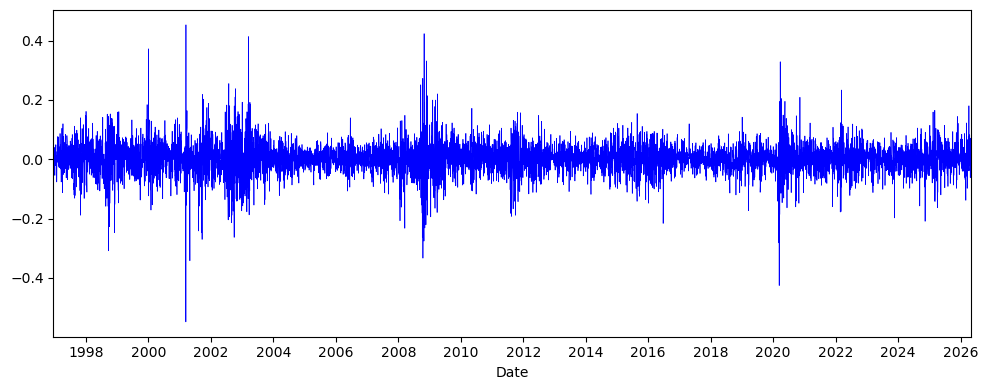

In [9]:
start_date = portfolio_returns.index.min()
end_date = portfolio_returns.index.max()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(portfolio_returns.index, portfolio_returns, color="blue", linewidth=0.5)

ax.set_xlabel("Date")

ax.set_xlim(start_date, end_date)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(False)

fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "DE_portfolio_log_returns.png"),
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()